# **Query Translation (Sorgu Dönüştürme)**

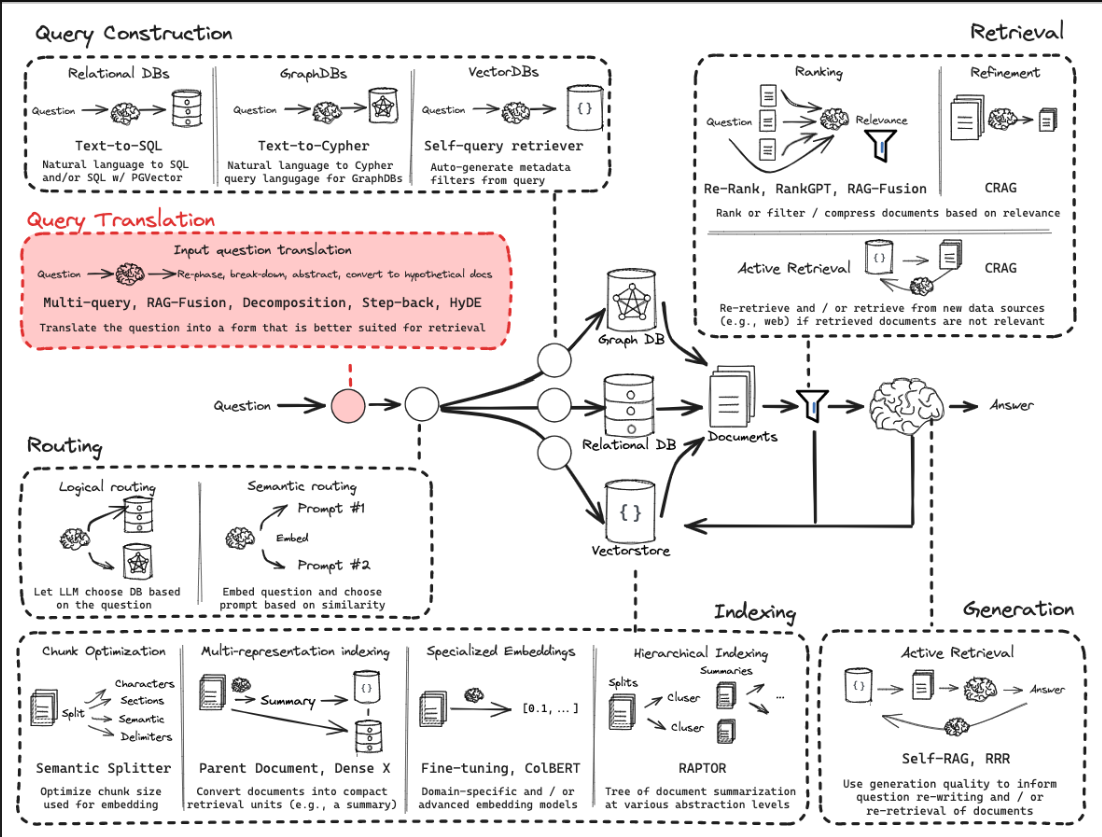

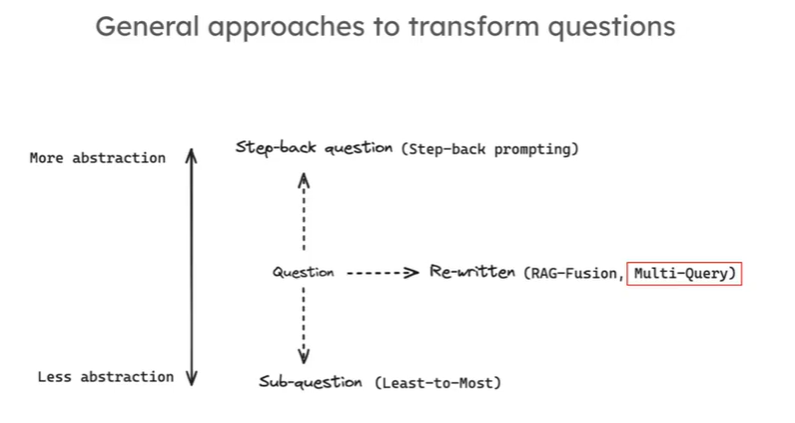

Geleneksel RAG (Retrieval-Augmented Generation) mimarilerinde kullanıcı tek bir soru sorar, bu soru bir embedding model ile vektöre dönüştürülür ve vektör veri tabanında mesafe odaklı (distance-based similarity search, örn. kosinüs benzerliği) arama yapılır.

Geleneksel RAG'in Kısıtlamaları:

Kelime/İfade Hassasiyeti: Kullanıcının soruyu sorma biçimi zayıfsa veya dokümandaki terminoloji ile tam eşleşmiyorsa vektör araması yetersiz veya yanlış dokümanlar getirebilir.

Tek Perspektif Riski: Karmaşık sorular tek bir arama sorgusu ile vektör uzayındaki doğru bilgi kümesine ulaşamayabilir.
Bu kısıtlamaları aşmak için Query Transformation (Sorgu Dönüştürme) yöntemleri kullanılır.

Input question translation (Girdi sorusu dönüştürme):

Amacı, kullanıcının sorduğu ham, eksik veya karmaşık soruyu alıp; arama motorunun veya veri tabanının en kolay eşleşme bulabileceği, zenginleştirilmiş formata çevirmektir. Yani "Kullanıcı ne sordu?" sorusundan ziyade, "Ben bu soruyu veri tabanına nasıl sorarsam en iyi sonuçları koparırım?" diye düşünür ve Retreival performansını artırmayı amaçlar. Aşağıda Retreival performasını artırmak için bazı Query Translation yöntemleri verilmiştir.



*   Re-written (RAG-Fusion, Multi-Query): Orijinal sorunun kapsamını daraltıp genişletmeden, yalnızca farklı ifadelerle yeniden yazılmasıdır.

* Step-back question (Step-back prompting): Oldukça spesifik ve dar kapsamlı bir soruyu bir adım geriye çekerek, o konunun temelindeki daha geniş ve kapsayıcı bir soruya dönüştürme işlemidir.Ne İşe Yarar?: Sistemin çok spesifik detaylarda kaybolmadan veya yanlış varsayımlar yapmadan önce, konunun temel prensiplerini veya ana bağlamını (background context) hatırlamasını sağlar. Örneğin Senin Sorduğun Orijinal Soru (Çok Spesifik): "Burnum fena akıyor, boğazım da ağrıyor. Evdeki o güçlü antibiyotiği hemen yutarsam yarına kesin iyileşir miyim?" Yapay Zekanın Arka Planda Ürettiği Step-back (Daha Soyut/Temel) Soru: "Antibiyotikler genel olarak hangi tür hastalıkları (virüs mü, bakteri mi) tedavi eder ve grip/soğuk algınlığı genelde hangisinden kaynaklanır?"


*   Sub-question (Least-to-Most): Karmaşık ve çok aşamalı (multi-hop reasoning) düşünme gerektiren bir soruyu, çok daha spesifik, somut ve küçük alt parçalara (sub-questions) bölme işlemidir.Ne İşe Yarar?: Büyük bir problemi tek seferde çözmeye çalışırken oluşabilecek halüsinasyonları engeller. Sistem problemi adım adım, mantıksal bir sırayla (en basit kısımdan başlayarak) çözer. Örnek: "Son 10 yılda Şampiyonlar Ligi'ni en çok kazanan takımın mevcut teknik direktörü nerelidir?" sorusunu önce "1. Son 10 yılda Şampiyonlar Ligi'ni en çok kazanan takım hangisidir?", sonra "2. Bu takımın şu anki teknik direktörü kimdir?", en son da "3. Bu kişi nerelidir?" şeklinde küçük ve doğrudan hedefe yönelik sorulara ayırmak.

İşte bu çeviri işlemini yaparken 9 temel yöntemi kullanır:

1. Multi-query (Çoklu Sorgu):
İnsanların aynı şeyi ifade etmek için farklı kelimeler kullanabileceği gerçeğine dayanır. Yapay zeka, senin sorduğun tek bir soruyu alır ve aynı anlama gelen 3-4 farklı soru cümlesi üretir.

# **1. Multi-query (Çoklu Sorgu):**

İnsanların aynı şeyi ifade etmek için farklı kelimeler kullanabileceği gerçeğine dayanır. Yapay zeka, senin sorduğun tek bir soruyu alır ve aynı anlama gelen 3-4 farklı soru cümlesi üretir Orjinal sorunun kapsamı değiştirilmez.

Örneğin:

"2026 pasaport uzatma bedeli kaç TL?"

"Pasaport süresini yenilemek için ne kadar ödemeliyim?"

"Güncel pasaport harç ve defter bedelleri nelerdir?"

"Süresi dolan pasaportu değiştirmenin maliyeti nedir?"

LLM'in dil anlama yeteneği kullanılarak kullanıcının orijinal sorusundan 5 farklı alternatif soru (farklı bakış açıları) türetilir. Bu 5 sorunun her biriyle vektör veritabanından dokümanlar çekilir ve sonuçlar birleştirilir.

Orijinal Soru -> LLM (Prompt) -> [5 Alternatif Soru] -> Parallel Retrieval -> Unique Union (Tekilleştirme) -> Final RAG Prompt -> LLM -> Yanıt


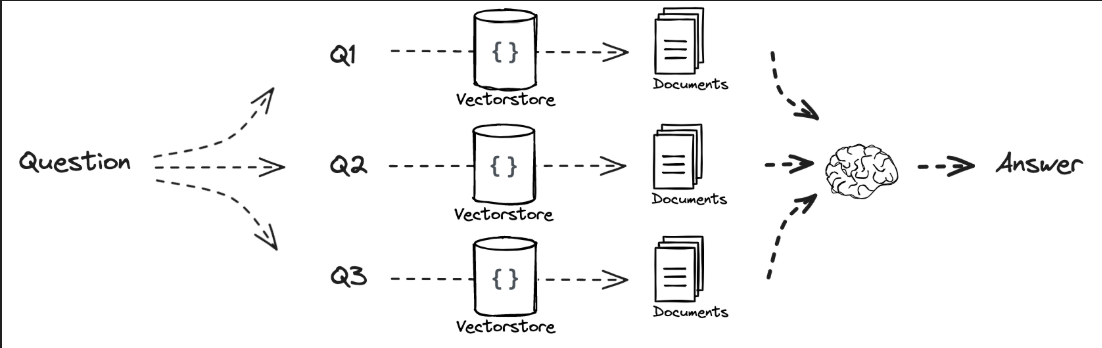

### **Environment**

`(1) Packages`

In [ ]:
%pip install -qU \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langchain-chroma \
langchain-text-splitters \
chromadb \
beautifulsoup4 \
tiktoken \
lxml \
langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 675.2/675.2 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.

\`(2) LangSmith`

https://docs.smith.langchain.com/

LangSmith, büyük dil modelleri (LLM) ve LangChain kullanılarak geliştirilen uygulamaları test etmek, değerlendirmek, izlemek (tracing) ve hata ayıklamak için kullanılan bulut tabanlı bir platformdur.

In [ ]:
import os

# "LANGCHAIN" yerine "LANGSMITH" kullanıyoruz ve ENDPOINT ekliyoruz
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "your-api-key"
os.environ["LANGSMITH_PROJECT"] = "RAG Query Translation"

`(3) API Keys`

In [ ]:
os.environ['OPENAI_API_KEY'] = os.environ['OPENAI_API_KEY'] = "your-api-key"

### **Indexing**

In [ ]:
import os
import bs4

from langchain_community.document_loaders import WebBaseLoader # Sayfanın HTML'ini alır.Daha sonra bunu LangChain'in anlayacağı Documentn esnelerine dönüştürür.
from langchain_text_splitters import RecursiveCharacterTextSplitter #LLM'ler çok uzun metinleri tek seferde okuyamaz. parçalamak için

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma #Bu Vector Database oluşturuyor.

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


####################################
# INDEXING
####################################

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=200, # son 200 karakter her iki chunkdda var sebep bilgi bölünmesini engellemek
)

splits = text_splitter.split_documents(docs)

embeddings = OpenAIEmbeddings() #Bu çok önemli.LLM değildir.Sadece metni sayılara dönüştürür.

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
) #bütün parçalar chromaya yazılıyor.sonra soruyla alakalı parçayı bulur.

retriever = vectorstore.as_retriever() # Artıkvektör veritabanında arama yapabilecek nesne oluştu.
#as_retriever() metoduna bir sayı verilmediğinde arka planda parametre otomatik olarak search_kwargs={"k": 4} ayarlanır.

/tmp/ipykernel_1027/2468579783.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader # Sayfanın HTML'ini alır.Daha sonra bunu LangChain'in anlayacağı Documentn esnelerine dönüştürür.


### **Sorgu Çeşitlendirme Prompt'u ve Zinciri**

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

template = """You are an AI language model assistant. Your task is to generate five
different versions of the given user question to retrieve relevant documents from a vector
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search.
Provide these alternative questions separated by newlines. Original question: {question}"""

prompt_perspectives = ChatPromptTemplate.from_template(template)

generate_queries = (
    prompt_perspectives #Şablona kullanıcı sorusu yerleştirilir.
    | ChatOpenAI(temperature=0) #Çıktıların tutarlı ve hedefe yönelik olması için sıfır sıcaklık ile 5 alternatif ürettirilir.
    | StrOutputParser() #Yanıt metin string'ine dönüştürülür.
    | (lambda x: x.split("\n")) #Oluşan metin satır satır bölünerek 5 elemanlı bir soru listesine dönüştürülür.
)


Multi-Query adımında temperature=0 seçilmesinin sebebi, LLM'in saçmalamadan (hallucination) veya konu dışına çıkmadan doğrudan orijinal soruya odaklı mantıklı alternatif sorular üretmesini sağlamaktır.Rastgeleliğin Sıfırlar ve yanıtta fanteziye, yaratıcılığa veya beklenmedik sapmalara izin verilmez.

### **Üretilen Soruların Kontrolü**

In [ ]:
# Test sorusu
question = "What is task decomposition for LLM agents?"

# Yalnızca soru üreten zinciri çalıştırıyoruz
sub_questions = generate_queries.invoke({"question": question})

# Üretilen alternatif soruları ekrana bastırma
print(f"Orijinal Soru: {question}\n")
print("--- Üretilen 5 Alternatif Soru ---")
for i, q in enumerate(sub_questions, start=1):
    print(f"{i}. {q}")


Orijinal Soru: What is task decomposition for LLM agents?

--- Üretilen 5 Alternatif Soru ---
1. 1. How do LLM agents utilize task decomposition?
2. 2. Can you explain the concept of task decomposition in relation to LLM agents?
3. 3. What role does task decomposition play in the functioning of LLM agents?
4. 4. How is task decomposition implemented by LLM agents?
5. 5. In what way does task decomposition benefit LLM agents?


### **Paralel Arama ve Doküman Tekilleştirme**

Türetilen 5 ayrı soru veritabanına sorulduğunda, farklı sorulardan aynı dokümanlar tekrar tekrar dönebilir. Bu nedenle doküman kümesini tekilleştirmek (deduplication) gerekir.

In [ ]:
from langchain_core.load import dumps, loads

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    # 1. İç içe listeyi düzleştir (flatten) ve dokümanları JSON string'e çevir
    #fonksiyonu LangChain doküman nesnesini serileştirilebilir bir JSON metnine dönüştürür.
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]

    # 2. Python set yapısı ile benzersiz (unique) olanları al
    # set() küme veri yapısı, mükemmel eşleşen JSON string'leri (yani mükemmel çakışan aynı dokümanları) otomatik olarak eler.
    unique_docs = list(set(flattened_docs))

    # 3. JSON string'leri tekrar LangChain Document nesnelerine dönüştür
    # loads(doc) ile benzersiz hale gelen string'ler tekrar orijinal Document nesnelerine çevrilir.
    return [loads(doc) for doc in unique_docs]

# Retrieval Chain
question = "What is task decomposition for LLM agents?"

#LangChain'in map() operatörü, generate_queries çıktısı olan 5 sorunun her birini paralel olarak retriever'a gönderir.
#Çıktı, iç içe geçmiş doküman listelerinden oluşan bir yapı olur (list[list[Document]]).

retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question": question})


/tmp/ipykernel_1027/1847174792.py:15: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  return [loads(doc) for doc in unique_docs]
/tmp/ipykernel_1027/1847174792.py:15: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc) for doc in unique_docs]


### **Nihai Cevap Üretim Zinciri (Final RAG Chain)**

In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)
llm = ChatOpenAI(temperature=0)

final_rag_chain = (
    {"context": retrieval_chain,  #retrieval_chain çalışarak 5 farklı alternatif sorgu üzerinden veritabanından en alakalı ve tekilleştirilmiş doküman birleşimini (context) getirir.
     "question": itemgetter("question")} #Orijinal soru (question) ve bu zenginleştirilmiş context, nihai prompt şablonuna aktarılarak GPT modelinden tam ve kapsamlı yanıt alınır.
    | prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question": question})


/tmp/ipykernel_1027/1847174792.py:15: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc) for doc in unique_docs]


'Task decomposition for LLM agents involves breaking down large tasks into smaller, manageable subgoals. This process enables efficient handling of complex tasks by the agents.'

Multi Query'nin Eksik Yönü: Dokümanlar birleştirilir ancak hangi dokümanın kaç farklı sorguda çıktığı veya arama sonuçlarındaki sırası (rank) dikkate alınmaz. İşte RAG-Fusion tam bu noktada devreye girer.

## **2. RAG-Fusion**

### **Akış**


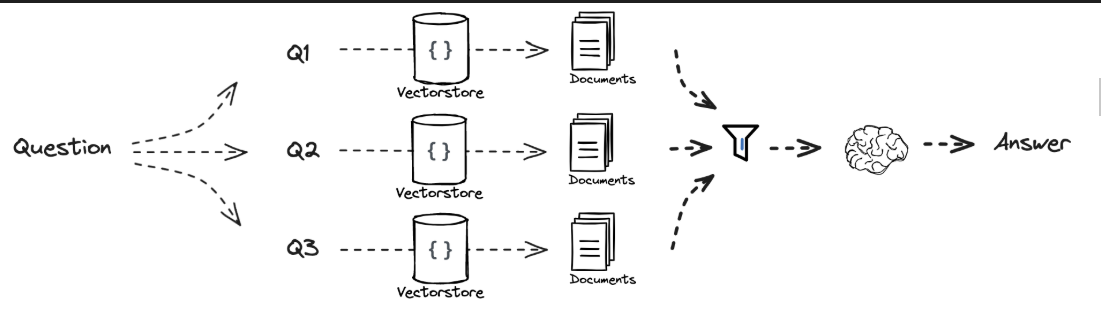

RAG-Fusion, Multi-Query fikrini bilgi erişimi (Information Retrieval - IR) literatüründeki Reciprocal Rank Fusion (RRF) sıralama algoritması ile birleştirerek bir adım öteye taşır.

RRF (Reciprocal Rank Fusion), bilgi getirme (information retrieval) sistemlerinde birden fazla farklı arama veya tavsiye algoritmasının sonuçlarını birleştirerek tek ve daha güçlü bir sıralama elde etmek için kullanılan bir yöntemdir.

RAG-Fusion 4 adımdan oluşur.

1. İlişkili Arama Sorgularının Üretilmesi

In [ ]:
from langchain_core.prompts import ChatPromptTemplate


# RAG-Fusion: Related
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

Üretilen sorular

In [ ]:
# Test sorusu
question = "What is task decomposition for LLM agents?"

# RAG-Fusion soru üretme zincirini tetikliyoruz
fusion_queries = generate_queries.invoke({"question": question})

# Ekrana yazdırma
print(f"Orijinal Soru: {question}\n")
print(f"--- Üretilen {len(fusion_queries)} RAG-Fusion Arama Sorgusu ---")
for i, q in enumerate(fusion_queries, start=1):
    print(f"{i}. {q}")


Orijinal Soru: What is task decomposition for LLM agents?

--- Üretilen 5 RAG-Fusion Arama Sorgusu ---
1. What are the principles of task decomposition in LLM agents?
2. How do LLM agents utilize task decomposition?
3. Can you explain the concept of task decomposition in LLM agents?
4. What role does task decomposition play in the functioning of LLM agents?
5. How is task decomposition implemented in LLM agents?


Uygun formata dönüştürme

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_queries = (
    prompt_rag_fusion
    | ChatOpenAI(temperature=0)
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

2. Paralel vektör araması

In [ ]:
from langchain_core.load import dumps, loads

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    # 1. İç içe listeyi düzleştir (flatten) ve dokümanları JSON string'e çevir
    #fonksiyonu LangChain doküman nesnesini serileştirilebilir bir JSON metnine dönüştürür.
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]

    # 2. Python set yapısı ile benzersiz (unique) olanları al
    # set() küme veri yapısı, mükemmel eşleşen JSON string'leri (yani mükemmel çakışan aynı dokümanları) otomatik olarak eler.
    unique_docs = list(set(flattened_docs))

    # 3. JSON string'leri tekrar LangChain Document nesnelerine dönüştür
    # loads(doc) ile benzersiz hale gelen string'ler tekrar orijinal Document nesnelerine çevrilir.
    return [loads(doc) for doc in unique_docs]

# Retrieval Chain
question = "What is task decomposition for LLM agents?"

#LangChain'in map() operatörü, generate_queries çıktısı olan 5 sorunun her birini paralel olarak retriever'a gönderir.
#Çıktı, iç içe geçmiş doküman listelerinden oluşan bir yapı olur (list[list[Document]]).

retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question": question})


/tmp/ipykernel_1027/1847174792.py:15: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc) for doc in unique_docs]


3. Reciprocal Rank Fusion (RRF) ile Yeniden Sıralama (Reranking)

In [ ]:
from langchain_core.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents
        and an optional parameter k used in the RRF formula

        Çoklu sıralı doküman listelerini alır ve RRF formülüne göre
        fused skor hesaplayıp dokümanları yeniden sıralar. """

    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    # 1. Her bir sorgunun sonuç listesini dön
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        # 2. Dokümanı ve onun listedeki sırasını (rank) al
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            # Doküman nesnesini JSON string'e dönüştür (Dictionary anahtarı olarak kullanabilmek için)
            doc_str = dumps(doc)

            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            # Belge henüz fused_scores sözlüğünde yer almıyorsa, onu başlangıç ​​puanı 0 olacak şekilde ekleyin
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0

            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]

            # Update the score of the document using the RRF formula: 1 / (rank + k)
            # 3. RRF Puanını güncelle: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    # 4. Dokümanları hesaplanan RRF puanına göre büyükten küçüğe sırala
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion #RAG-Fusion arama zinciri
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)

/tmp/ipykernel_1027/3920550210.py:38: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


6

4 soru başına 4 sorgu toplam 16 belge yapar.
Mükerrerler Elendi & Skorlandı: Bu 16 dokümanın birçoğu birbirinin aynısıydı (aynı doküman farklı sorgularda tekrar çıktı).

reciprocal_rank_fusion fonksiyonu bu 16 dokümanı inceledi, tekrarları birleştirip her birinin RRF skorunu hesapladı.

Sonuçta veri tabanından çekilen benzersiz (unique) doküman sayısı 6 olduğu için len(docs) çıktısı 6 oldu.

RRF ranklarının gösterilmesi

In [ ]:
for doc, score in docs:
    print(f"RRF Skoru: {score:.5f} | Doküman Özeti: {doc.page_content[:80]}...")

RRF Skoru: 0.06586 | Doküman Özeti: The system comprises of 4 stages:
(1) Task planning: LLM works as the brain and ...
RRF Skoru: 0.06454 | Doküman Özeti: Subgoal and decomposition: The agent breaks down large tasks into smaller, manag...
RRF Skoru: 0.04866 | Doküman Özeti: Task decomposition can be done (1) by LLM with simple prompting like "Steps for ...
RRF Skoru: 0.03252 | Doküman Özeti: Challenges in long-term planning and task decomposition: Planning over a lengthy...
RRF Skoru: 0.03200 | Doküman Özeti: Component One: Planning#
A complicated task usually involves many steps. An agen...
RRF Skoru: 0.01667 | Doküman Özeti: }
]
Challenges#
After going through key ideas and demos of building LLM-centered...


4. Final RAG Zinciri ve arama yönetimi

In [ ]:
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain_rag_fusion,
     "question": itemgetter("question")}
    | prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

/tmp/ipykernel_1027/3920550210.py:38: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


'Task decomposition for LLM agents involves breaking down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks. This process can be done by LLM through simple prompting, task-specific instructions, or with human inputs.'

## **3. Decompsition**

Decomposition, karmaşık veya çok adımlı (multi-step) tek bir soruyu, bağımsız veya birbiriyle ilintili daha küçük ve yönetilebilir alt sorulara (sub-questions / sub-problems) bölme tekniğidir.

Problem Tanımı:
Kullanıcı bazen çok genel veya birden fazla parçadan oluşan karmaşık bir soru sorar:
Örnek: "LLM tabanlı otonom ajan sistemlerinin ana bileşenleri nelerdir?"

Vektör veritabanından tek bir aramada tüm bileşenleri tek seferde bulmak zordur. Decomposition ile bu ana soru 3 alt soruya bölünür:

LLM ajanlarında hafıza (memory) bileşenleri nelerdir?
LLM ajanlarında planlama (planning) yetenekleri nelerdir?
LLM ajanlarında araç kullanımı (tool use) nasıl çalışır?

1. Alt soruların üretilmesi

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answers in isolation. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# LLM
llm = ChatOpenAI(temperature=0)

# Chain
generate_queries_decomposition = (prompt_decomposition | llm | StrOutputParser() | (lambda x: x.split("\n")))

# Run
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_queries_decomposition.invoke({"question":question})

In [ ]:
questions

['1. What is LLM technology and how does it work in autonomous agent systems?',
 '2. What are the specific components that make up an autonomous agent system powered by LLM?',
 '3. How do the main components of an LLM-powered autonomous agent system interact with each other to achieve autonomy?']

2. Alt soruların yanıtlanması

2.1 Answer Recursively (Özyinelemeli / Ardışık Yanıtlama)

Bu yöntemde alt sorular sırayla (birbirini takip edecek şekilde) yanıtlanır.

Çalışma Mantığı:
Q_1 sorusu için RAG çalıştırılır, dokümanlar çekilir ve A_1 yanıtı üretilir.

Q_2 sorusu yanıtlanırken, vektör veritabanından çekilen dokümanların yanında önceki adımda üretilen (Q_1, A_1) soru-cevap çifti de arka plan bilgisi (q_a_pairs) olarak LLM'e iletilir!

Q_3 yanıtlanırken hem Q_3'ün dokümanları hem de (Q_1, A_1) + (Q_2, A_2) geçmişi LLM'e verilir.

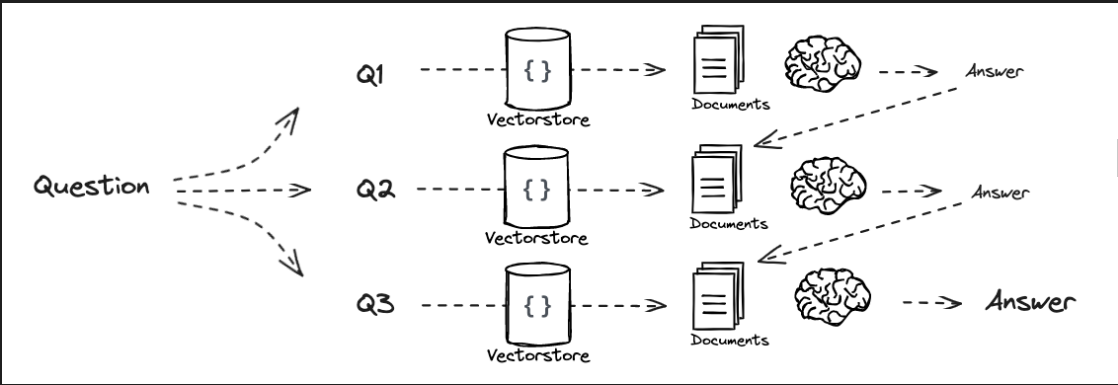

1.   [Soru 1] -> RAG -> Yanıt 1
2.   [Soru 2 + Yanıt 1] -> RAG -> Yanıt 2
3.   [Soru 3 + Yanıt 1 + Yanıt 2] -> RAG -> Final Yanıt

In [ ]:
# Prompt
template = """Here is the question you need to answer:

\n --- \n {question} \n --- \n #

Here is any available background question + answer pairs:

\n --- \n {q_a_pairs} \n --- \n

Here is additional context relevant to the question:

\n --- \n {context} \n --- \n

Use the above context and any background question + answer pairs to answer the question: \n {question}
"""

decomposition_prompt = ChatPromptTemplate.from_template(template)

In [ ]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

#Bu yardımcı fonksiyon, modele sorulan alt soruyu ve modelin ürettiği cevabı alıp düzenli bir metin formatına (string) çevirir.
def format_qa_pair(question, answer):
    """Format Q and A pair"""

    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

# llm
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

q_a_pairs = "" #Burası sistemin hafızasıdır. Döngü başlamadan önce boştur. Çözülen her alt sorunun cevabı buraya eklenecektir.
#for q in questions: döngüsü, daha önceden ayrıştırılmış alt soruları sırayla işler. Her bir soru için bir LangChain zinciri (rag_chain) oluşturulur ve çalıştırılır:
for q in questions:

    rag_chain = (
    {"context": itemgetter("question") | retriever,  #O anki alt soru (q) alınır ve vektör veri tabanına (retriever) gönderilerek soruyla ilgili dokümanlar getirilir.
     "question": itemgetter("question"), #: O an çözülmesi gereken güncel alt soruyu doğrudan alır.
     "q_a_pairs": itemgetter("q_a_pairs")} #O ana kadar çözülmüş olan önceki soruların ve cevapların geçmişini alır.
    | decomposition_prompt
    | llm
    | StrOutputParser())

    answer = rag_chain.invoke({"question":q,"q_a_pairs":q_a_pairs})
    q_a_pair = format_qa_pair(q,answer)
    q_a_pairs = q_a_pairs + "\n---\n"+  q_a_pair

In [ ]:
print(q_a_pairs)


---
Question: 1. What is LLM technology and how does it work in autonomous agent systems?
Answer: LLM technology refers to large language models, which are powerful AI models capable of processing and generating human-like text. In autonomous agent systems, LLM functions as the agent's brain, providing the system with the ability to understand and generate natural language text. This allows the autonomous agent to interact with users, gather information from various sources, make decisions, and perform tasks based on the input it receives. LLM technology enables autonomous agents to handle complex tasks such as scientific discovery, autonomous design, planning, and performance of experiments by leveraging its language processing capabilities.
---
Question: 2. What are the specific components that make up an autonomous agent system powered by LLM?
Answer: The specific components that make up an autonomous agent system powered by LLM include:

1. LLM (Large Language Model): LLM function

In [ ]:
answer

"In an LLM-powered autonomous agent system, the main components interact with each other to achieve autonomy through a coordinated approach. The LLM functions as the agent's brain, providing the system with the ability to understand and generate natural language text. This allows the agent to interact with users, gather information, make decisions, and perform tasks based on the input it receives.\n\nAdditionally, the system incorporates memory mechanisms to enable agents to behave based on past experiences. Planning mechanisms are integrated to assist agents in making decisions and strategizing their actions. Reflection mechanisms allow agents to analyze their own behavior and interactions, enhancing their ability to learn and adapt.\n\nFurthermore, the system may contain expert modules that specialize in specific tasks or domains. LLM works as a router to direct inquiries to the most suitable expert module, whether neural (e.g., deep learning models) or symbolic (e.g., math calculato

2.2 Answer Individually (Bireysel / Bağımsız Yanıtlama ve Sentezleme)

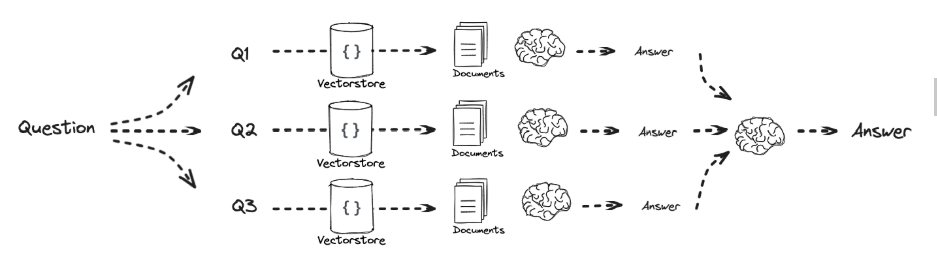

Bu yöntemde her alt soru birbirinden tamamen bağımsız şekilde yanıtlanır ve en sonunda tek bir sentez adımı ile birleştirilir.

Çalışma Mantığı:
Üretilen 3 alt soru (Q_1, Q_2, Q_3) için bağımsız RAG zincirleri çalıştırılır ve A_1, A_2, A_3 yanıtları alınır.

Elde edilen tüm Soru-Cevap çiftleri tek bir metin bloğunda birleştirilir (format_qa_pairs).

Bir Sentez Prompt'u (Synthesis) kullanılarak LLM tüm bu bilgileri ana sorunun yanıtı olacak şekilde birleştirir.

*   [Soru 1] -> RAG -> Yanıt 1 \
*   [Soru 2] -> RAG -> Yanıt 2  ===> [Sentez Prompt'u] -> Final Birleşik Yanıt
*   [Soru 3] -> RAG -> Yanıt 3 /

Alt soruların bağımsız cevaplandırılması

In [ ]:
# Answer each sub-question individually

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langsmith import Client


# RAG prompt
#LangChain Hub üzerinden, topluluk tarafından sıkça kullanılan standart ve optimize edilmiş bir RAG prompt şablonu
#(bağlamı ve soruyu alıp cevap üreten bir şablon) projeye dahil edilir
client = Client()
prompt_hub_rag = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)


def retrieve_and_rag(question,prompt_rag,sub_question_generator_chain):
    """RAG on each sub-question"""

    # Use our decomposition /
    sub_questions = sub_question_generator_chain.invoke({"question":question}) #alt soruların üretilmesi

    # Initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:

        # Retrieve documents for each sub-question
        #her alt soru için cevap üretilmesi
        retrieved_docs = retriever.invoke(sub_question)

        # Use retrieved documents and sub-question in RAG chain
        # Bulunan dokümanlar (context) ve o anki alt soru (question), Hub'dan çektiğimiz hazır şablona yerleştirilerek Dil Modeline (llm) verilir.
        # LLM'in ürettiği metin StrOutputParser ile temizlenir ve answer değişkenine atanır.
        answer = (prompt_rag | llm | StrOutputParser()).invoke({"context": retrieved_docs,
                                                                "question": sub_question})
        rag_results.append(answer)

    return rag_results,sub_questions

# Wrap the retrieval and RAG process in a RunnableLambda for integration into a chain
answers, questions = retrieve_and_rag(question, prompt_hub_rag, generate_queries_decomposition)

In [ ]:
questions

['1. What is LLM technology and how does it work in autonomous agent systems?',
 '2. What are the specific components that make up an LLM-powered autonomous agent system?',
 '3. How do the main components of an LLM-powered autonomous agent system interact with each other to enable autonomous behavior?']

In [ ]:
answers

['LLM technology functions as the brain of autonomous agent systems. It is complemented by key components to enable autonomous decision-making and actions. LLM-powered agents can handle tasks like scientific discovery, design, planning, and performance of experiments.',
 "An LLM-powered autonomous agent system consists of LLM as the agent's brain, along with memory, planning, and reflection mechanisms. These components enable the agent to behave based on past experiences and interact with other agents. Additionally, the system may include tools for browsing the internet, reading documentation, executing code, and calling robotics experimentation APIs.",
 "In an LLM-powered autonomous agent system, LLM functions as the agent's brain and is complemented by memory, planning, and reflection mechanisms. These components enable the agent to behave based on past experiences and interact with other agents. The design of generative agents combines these components to facilitate autonomous behav

In [ ]:
print(context)

Question 1: 1. What is LLM technology and how does it work in autonomous agent systems?
Answer 1: LLM technology functions as the brain of autonomous agent systems. It is complemented by key components to enable autonomous decision-making and actions. LLM-powered agents can handle tasks like scientific discovery, design, planning, and performance of experiments.

Question 2: 2. What are the specific components that make up an LLM-powered autonomous agent system?
Answer 2: An LLM-powered autonomous agent system consists of LLM as the agent's brain, along with memory, planning, and reflection mechanisms. These components enable the agent to behave based on past experiences and interact with other agents. Additionally, the system may include tools for browsing the internet, reading documentation, executing code, and calling robotics experimentation APIs.

Question 3: 3. How do the main components of an LLM-powered autonomous agent system interact with each other to enable autonomous behav

Soru-Cevapların sentezlenmesi

In [ ]:
def format_qa_pairs(questions, answers):
    """Format Q and A pairs"""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pairs(questions, answers)

# Prompt
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an answer to the question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":context,"question":question})

"The main components of an LLM-powered autonomous agent system include LLM as the agent's brain, memory for storing past experiences, planning mechanisms for decision-making, and reflection mechanisms for self-improvement. These components work together to enable autonomous behavior, such as scientific discovery, experiment planning, and interaction with other agents. Additionally, tools for browsing the internet, reading documentation, executing code, and calling robotics experimentation APIs may be included to enhance the agent's capabilities."

# **4. Step Back**

Spesifik ve detaylı bir soru sorulduğunda, LLM'den önce bu soruyu daha genel, soyut ve kavramsal (higher-level / generic) bir soruya dönüştürmesi istenir.

Ardından veri tabanından hem spesifik soru için hem de genel (step-back) soru için doküman çekilerek çift bağlamlı (dual-context) bir yanıt üretilir.

Örneğin

"The Police müzik grubunun üyeleri yasal tutuklama yapabilir mi?"

"The Police grubu hakkında genel bilgi nedir?" (Grup polis mi yoksa müzik grubu mu?)

In [ ]:
# Few Shot Examples
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate

# Burada modelden tam olarak ne beklediğimizi gösteren bir sözlük (dictionary) listesi oluşturulur:
examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "what can the members of The Police do?",
    },
    {
        "input": "Jan Sindel’s was born in what country?",
        "output": "what is Jan Sindel’s personal history?",
    },
]

# We now transform these to example messages
#LLM'ler sohbet (chat) formatında çalışır. Bu adımda, yukarıdaki örnekler LangChain'in anlayacağı bir "Kullanıcı (human) - Yapay Zeka (ai)" diyalog şablonuna oturtulur.
#Yani sistem LLM'e şu yanılsamayı verir: "Bak, daha önce bir kullanıcı sana 'input' sordu ve sen de ona 'output' olarak bu genel soruyu ürettin."
example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)

# Bu fonksiyon, hazırladığınız examples listesini alır ve example_prompt formatından geçirerek dinamik bir bileşen haline getirir.
# Eğer ileride listeye 10 tane daha örnek eklerseniz, bu yapı hepsini otomatik olarak işleyip diyalog geçmişi gibi modele sunar.
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", #Modele rolü ve görevi verilir: "Sen dünya bilgisi konusunda bir uzmansın. Görevin bir adım geri çekilip soruyu cevaplaması daha kolay olan daha genel bir soruya dönüştürmek..."
            """You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Here are a few examples:""",
        ),
        # Few shot examples
        few_shot_prompt, #Yukarıda hazırladığımız örnek diyaloglar sisteme eklenir
        # New question
        ("user", "{question}"), #kullanıcının gerçekte sorduğu yeni soru ({question}) yer alır.
    ]
)

"Step-Back" (Bir Adım Geri Çekilme) şablonunu çalıştırarak (execute) eyleme dönüştüren kısım

In [ ]:
generate_queries_step_back = prompt | ChatOpenAI(temperature=0) | StrOutputParser()
question = "What is task decomposition for LLM agents?"
generate_queries_step_back.invoke({"question": question})

'What is the process of breaking down tasks for LLM agents?'

Önceki adımlarda ürettiğiniz "genel soruyu" ve kullanıcının "orijinal spesifik sorusunu" bir araya getirerek, modele hem geniş bir arka plan bilgisi hem de nokta atışı detaylar sunar ve nihai cevabı üretir.

In [ ]:
# Response prompt
# Dil Modeline (LLM) nasıl davranması gerektiğini söyler:
response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, ignore them if they are not relevant.

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        # Kullanıcının spesifik sorusu (örneğin: "LLM ajanları için görev ayrıştırma nedir?")
        # doğrudan vektör veri tabanına (retriever) gönderilir. Elde edilen detaylı teknik belgeler buraya atanır.
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever,

        # Retrieve context using the step-back question
        # Orijinal soru, bir önceki adımda yazdığınız generate_queries_step_back zincirinden geçirilir.
        # Üretilen daha genel soru (örneğin: "LLM ajanlarının bileşenleri nelerdir?") vektör veri tabanına gönderilir.
        "step_back_context": generate_queries_step_back | retriever,
        # Pass on the question

        #Şablonun en altındaki soru kısmını doldurmak için kullanıcının asıl sorusu hiçbir değişime uğramadan doğrudan aktarılır.
        "question": lambda x: x["question"],
    }
    | response_prompt
    | ChatOpenAI(temperature=0)
    | StrOutputParser()
)

chain.invoke({"question": question})

'Task decomposition for LLM agents refers to the process of breaking down large tasks into smaller, more manageable subgoals. This approach enables LLM agents to efficiently handle complex tasks by dividing them into smaller components that can be tackled sequentially or in parallel. Task decomposition allows LLM agents to plan ahead, understand the steps involved in a task, and allocate resources effectively to achieve the desired outcome.\n\nIn the context of LLM agents, task decomposition can be achieved in several ways. One method is through simple prompting, where the agent is guided to break down a task by asking questions like "Steps for XYZ" or "What are the subgoals for achieving XYZ." Another approach involves providing task-specific instructions to the agent, such as asking it to "Write a story outline" for the task of writing a novel. Additionally, human inputs can also be used to assist in task decomposition, allowing for a more collaborative approach to breaking down comp

# **5. HyDE**

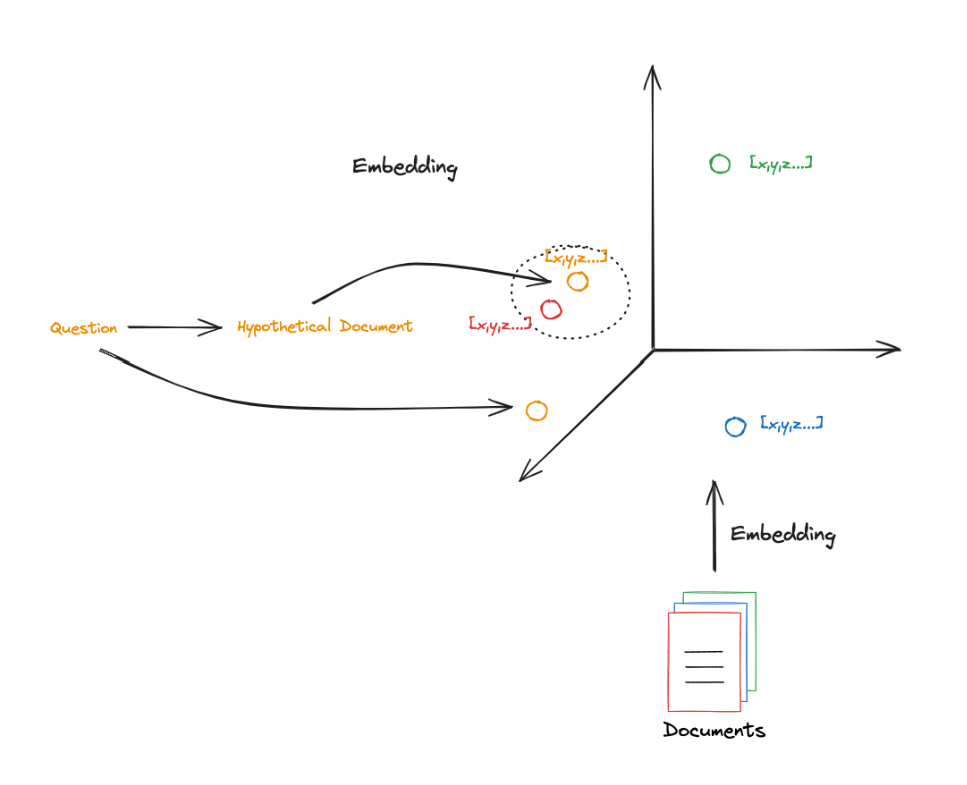

Geleneksel RAG sistemlerinde kullanıcının sorusu ile veritabanındaki doküman doğrudan karşılaştırılır:

Sorgu: Genellikle kısadır, soru kipi içerir ve az sayıda anahtar kelimeden oluşur (Örn: "Task decomposition nedir?").
Doküman: Uzundur, bildirim/açıklama cümlesidir ve akademik/teknik bir dille yazılmıştır.

Bir sorunun vektör (embedding) temsilatı ile bir metin açıklamasının vektör temsilatı vektör uzayında birbirinden farklı yerlere düşebilir.

HyDE bu uyumsuzluğu çözmek için Soru --> Doküman aramasını
Doküman --> Doküman aramasına dönüştürür.

*   [Kullanıcı Sorusu]
*   [Adım 1: LLM Hayali/Varsayımsal Bir Yanıt Dokümanı Yazar] (Hypothetical Document)
*   [Adım 2: Bu Hayali Dokümanın Vektörü Alınır ve Veri Tabanında Aranır] (retriever)
*   [Adım 3: Çekilen Gerçek Dokümanlar Kullanılarak Doğru Yanıt Üretilir]



Örneğin

"Ateş düşürücü olarak ne içilir?"

HyDE'ın Ürettiği Varsayımsal Belge (LLM Çıktısı):

"Ateş düşürücü (antipiretik) amacıyla genellikle parasetamol veya ibuprofen etken maddeli farmakolojik ajanlar tercih edilmektedir. Bu ilaçlar hipotalamustaki ısı düzenleyici merkezi etkileyerek..."

Sonuç: Veri tabanında "Ateş düşürücü olarak ne içilir?" cümlesini aratmak yerine yukarıdaki tıbbi terimlerle dolu varsayımsal metni arattığınızda, sistem size doğrudan doğru tıp makalelerini ve ilaç prospektüslerini getirecektir.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# HyDE document generation
template = """Please write a scientific paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_docs_for_retrieval = (
    prompt_hyde | ChatOpenAI(temperature=0) | StrOutputParser()
)

# Run
question = "What is task decomposition for LLM agents?"
generate_docs_for_retrieval.invoke({"question":question})

"Task decomposition is a fundamental concept in the field of reinforcement learning and artificial intelligence, particularly for Large Language Models (LLMs) agents. Task decomposition refers to the process of breaking down a complex task into smaller, more manageable sub-tasks or components. This allows the agent to effectively tackle the overall task by focusing on individual components sequentially or in parallel.\n\nIn the context of LLM agents, task decomposition is crucial for improving the efficiency and effectiveness of the agent's decision-making process. By breaking down a complex task into smaller sub-tasks, the agent can better understand the underlying structure of the task and identify the most relevant information needed to make informed decisions. This can lead to more accurate and timely responses to user queries or commands.\n\nFurthermore, task decomposition can also help LLM agents handle tasks that require a combination of different skills or knowledge domains. By

In [ ]:
# Retrieve
retrieval_chain = generate_docs_for_retrieval | retriever
retrieved_docs = retrieval_chain.invoke({"question":question})
retrieved_docs

[Document(id='88b45ec7-1fa1-4032-ad80-24ae8869b1f4', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.'),
 Document(id='c17dbf5c-91dc-4db7-8642-295df34bed33', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.'),
 Document(id='ce900001-442b-4f05-b569-649805df0e09', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#'),
 Document(id='1

In [ ]:
# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":retrieved_docs,"question":question})

'Task decomposition for LLM agents involves breaking down large tasks into smaller, manageable subgoals using simple prompting, task-specific instructions, or human inputs. This allows LLM agents to efficiently handle complex tasks by dividing them into more manageable components.'

# **6. Contextual Query Rewrite (Sohbet Bağlamında Yeniden Yazma)**

Contextual Query Rewrite (Bağlamsal Sorgu Yeniden Yazma), sohbet geçmişine sahip bir RAG (Retrieval-Augmented Generation) sistemi kurarken karşılaşılan en büyük sorunu çözer: Eksik referanslar.

Örneğin, kullanıcı önce "Task decomposition nedir?" diye sorar, sistem cevaplar. Ardından kullanıcı "Peki bu nasıl çalışır?" diye sorar. Vektör veri tabanına doğrudan "Peki bu nasıl çalışır?" cümlesini yollarsanız hiçbir şey bulamazsınız; çünkü "bu" kelimesinin ne anlama geldiğini bilemez. Contextual Query Rewrite, sohbet geçmişine bakarak o ikinci soruyu arka planda "Task decomposition nasıl çalışır?" şekline dönüştürür (rewrite) ve veri tabanında bunu aratır.

Henüz doküman aramıyor veya cevap üretmiyor. Sadece kullanıcının sorusunu, sohbet geçmişini kullanarak daha anlaşılır bir soruya dönüştürecek zinciri hazırlıyor

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

# LLM
llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0
)

# Kullanıcının sorusunu sohbet geçmişini kullanarak yeniden yazan prompt
contextualize_q_system_prompt = """
Given a chat history and the latest user question,
which might reference context in the chat history,
formulate a standalone question that can be understood
without the chat history.

Do NOT answer the question.
Only rewrite it if necessary.
Otherwise return it unchanged.
"""

contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt),
        MessagesPlaceholder(variable_name="chat_history"),
        ("human", "{input}"),
    ]
)

# Soru yeniden yazma zinciri
rewrite_chain = (
    contextualize_q_prompt
    | llm
    | StrOutputParser()
)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

rewrite_chain = (
    contextualize_q_prompt
    | llm
    | StrOutputParser()
)

#history_aware_retriever, kullanıcının sorusunu önce sohbet geçmişiyle netleştirir, sonra bu netleştirilmiş soruyla vektör veritabanında arama yapar.
history_aware_retriever = RunnableLambda(
    lambda x: retriever.invoke(
        rewrite_chain.invoke({
            "chat_history": x["chat_history"],
            "input": x["input"]
        })
    )
)

Önceki adımda tasarladığınız şablonu, sizin Chroma veritabanı arama nesnenizle (retriever) ve LLM ile birleştirir.

Sistem artık doğrudan vektör araması yapmaz. Önce soruyu LLM'e gönderip yeniden yazdırır (Hücre 2), ardından veri tabanınızda (Chroma) bu yeniden yazılmış (temizlenmiş) versiyonu aratır.

In [ ]:
from langchain_core.runnables import RunnablePassthrough

# Modelin, bulunan dokümanları (bağlamı) kullanarak asıl cevabı üreteceği prompt
qa_system_prompt = """You are an assistant for question-answering tasks. \
Use the following pieces of retrieved context to answer the question. \
If you don't know the answer, just say that you don't know. \
Use three sentences maximum and keep the answer concise.\

{context}"""

chat_history = [
    HumanMessage(content="What is task decomposition for LLM agents?"),
    AIMessage(content="Task decomposition is the process of breaking a complex task into smaller subtasks.")
]

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", qa_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}"),
    ]
)

# Dokümanları ve LLM'i birleştirerek QA (Soru-Cevap) zincirini oluşturuyoruz
question_answer_chain = (
    RunnablePassthrough.assign(
        context=lambda x: "\n\n".join(
            doc.page_content for doc in x["context"]
        )
    )
    | qa_prompt
    | llm
    | StrOutputParser())

In [ ]:
question = "Why is it important?"

# 1. Soruyu yeniden yaz
rewritten_question = rewrite_chain.invoke(
    {
        "chat_history": chat_history,
        "input": question
    }
)

print("=" * 60)
print("Original Question:")
print(question)

print("\nRewritten Question:")
print(rewritten_question)

# 2. Retriever ile dokümanları getir
docs = retriever.invoke(rewritten_question)

print("\n" + "=" * 60)
print("Retrieved Documents:\n")

for i, doc in enumerate(docs, 1):
    print(f"Document {i}")
    print(doc.page_content[:500])   # ilk 500 karakter
    print("-" * 60)

# 3. QA zincirine gönder
answer = question_answer_chain.invoke(
    {
        "input": question,
        "chat_history": chat_history,
        "context": docs
    }
)

print("\n" + "=" * 60)
print("Final Answer:\n")
print(answer)

Original Question:
Why is it important?

Rewritten Question:
Why is task decomposition important for LLM agents?

Retrieved Documents:

Document 1
Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
------------------------------------------------------------
Document 2
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
------------------------------------------------------------
Document 3
Challenges in long-term planning and task decomposition: Planning over a lengthy history and effectively exploring the solution space remain challenging. LLMs struggle to adjust plans when faced with unexpected errors, making them less robust compared to humans who learn from trial and error.
------------------------------------------------------------
Document 4
The system comprises of 4 stages:
(1) Task planning: LL

# **7. Query Expansion**

Vektör arama sistemleri, kullanıcının yazdığı sorguya semantik olarak en yakın dokümanları bulmaya çalışır. Ancak kullanıcı her zaman en uygun ifadeyi kullanmaz.

Örneğin kullanıcı şöyle bir soru sorsun:

What is RAG?

Veritabanındaki dokümanlarda ise şu ifadeler geçiyor olabilir:

Retrieval-Augmented Generation
Retrieval enhanced LLM
Retrieval pipeline
External knowledge retrieval

Kullanıcı sadece RAG yazdığı için bazı alakalı dokümanlar yeterince yüksek benzerlik puanı alamayabilir.

İşte Query Expansion bu problemi çözmeye çalışır.Tek bir sorgu yerine, aynı anlamı taşıyan daha kapsamlı bir sorgu oluşturulur.

What is RAG?  --> What is Retrieval-Augmented Generation (RAG)?
Explain how retrieval works in LLMs.
Describe external knowledge retrieval for large language models.

```
User Question
      │
      ▼
Query Expansion
      │
      ▼
Expanded Query
      │
      ▼
Retriever
      │
      ▼
Vector DB
      │
      ▼
LLM
```



In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

query_expansion_prompt = ChatPromptTemplate.from_messages(
[
    (
        "system",
        """
You are an expert search assistant.

Expand the user's search query to improve semantic retrieval.

Rules:
- Keep the original intent.
- Add important related concepts.
- Add synonyms if appropriate.
- Do not answer the question.
- Return only one expanded search query.
"""
    ),

    ("human","{question}")
])

query_expansion_chain = (
    query_expansion_prompt
    | llm
    | StrOutputParser()
)

In [ ]:
question = "What is task decomposition for LLM agents?"

expanded_query = query_expansion_chain.invoke(
    {
        "question": question
    }
)

print("=" * 60)
print("Original Query:")
print(question)

print("\nExpanded Query:")
print(expanded_query)

Original Query:
What is task decomposition for LLM agents?

Expanded Query:
What is task decomposition and hierarchical reinforcement learning for Large Language Models (LLMs)?


In [ ]:
docs = retriever.invoke(expanded_query)

print("=" * 60)
print("Retrieved Documents\n")

for i, doc in enumerate(docs, start=1):
    print(f"Document {i}")
    print("-" * 40)
    print(doc.page_content[:500])
    print()

Retrieved Documents

Document 1
----------------------------------------
be a combination of task-specific discrete actions and the language space. The former enables LLM to interact with the environment (e.g. use Wikipedia search API), while the latter prompting LLM to generate reasoning traces in natural language.

Document 2
----------------------------------------
[9] Laskin et al. “In-context Reinforcement Learning with Algorithm Distillation” ICLR 2023.
[10] Karpas et al. “MRKL Systems A modular, neuro-symbolic architecture that combines large language models, external knowledge sources and discrete reasoning.” arXiv preprint arXiv:2205.00445 (2022).

Document 3
----------------------------------------
Challenges in long-term planning and task decomposition: Planning over a lengthy history and effectively exploring the solution space remain challenging. LLMs struggle to adjust plans when faced with unexpected errors, making them less robust compared to humans who learn from trial



```
User
│
│  What is task decomposition for LLM agents?
▼
──────────────────────────────────────────────
Query Expansion (LLM)
──────────────────────────────────────────────
│
▼
Explain the concept of task decomposition for
LLM agents including hierarchical planning,
subtasks, reasoning and autonomous workflows.
│
▼
──────────────────────────────────────────────
Chroma Retriever
──────────────────────────────────────────────
│
▼
Top-4 Documents
│
▼
──────────────────────────────────────────────
Question Answer Chain
──────────────────────────────────────────────
│
▼
ChatOpenAI
│
▼
Final Answer
```



# **8. Self-Query Retrieval**

Self-Query Retrieval, LLM'in sadece arama sorgusunu üretmediği, aynı zamanda metadata filtrelerini de oluşturduğu retrieval yöntemidir.

Yani kullanıcı doğal dilde bir soru sorar, LLM bu soruyu iki parçaya ayırır:

Semantic Query → Embedding ile aranacak metin
Metadata Filter → Veritabanında uygulanacak filtre

Show me papers about task decomposition after 2023. Burada after normal retreiver'ın arasına karışır.

task decomposition --> Semantic Query
Metadata Filter --> year > 2023


author, year, section gibi alanlar yoksa Self-Query Retrieval'ın asıl gücünü gösteremezsin.



```
User Question
        │
        ▼
LLM
        │
        ├───────────────┐
        │               │
        ▼               ▼
Semantic Query     Metadata Filter
        │               │
        └──────┬────────┘
               ▼
          Vector Database
               │
               ▼
        Relevant Documents
```



In [ ]:
from langchain_core.documents import Document

documents = [

    Document(
        page_content="Task decomposition breaks a complex task into smaller subtasks.",
        metadata={
            "section": "Task Decomposition",
            "author": "Lilian Weng",
            "year": 2023
        }
    ),

    Document(
        page_content="Reflection allows an LLM agent to improve its reasoning by analyzing previous mistakes.",
        metadata={
            "section": "Reflection",
            "author": "Lilian Weng",
            "year": 2023
        }
    ),

    Document(
        page_content="Memory enables an LLM agent to remember previous interactions.",
        metadata={
            "section": "Memory",
            "author": "Lilian Weng",
            "year": 2023
        }
    ),

    Document(
        page_content="Planning helps an LLM divide complicated objectives into manageable steps.",
        metadata={
            "section": "Planning",
            "author": "Lilian Weng",
            "year": 2024
        }
    )

]

In [ ]:
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=OpenAIEmbeddings(),
    collection_name="agent_demo"
)

In [ ]:
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k":3
    }
)

In [ ]:
metadata_description = """
The vector database contains these metadata fields:

section:
Task Decomposition
Reflection
Memory
Planning

author:
Author of the document.

year:
Publication year.
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

self_query_prompt = ChatPromptTemplate.from_messages(
[
(
"system",
f"""
You are an expert retrieval planner.

Your job is to convert a user's request into:

1. semantic_query
2. metadata_filter

Metadata:

{metadata_description}

Return ONLY JSON.
"""
),

("human","{question}")

]
)

In [ ]:
from langchain_core.output_parsers import JsonOutputParser

parser = JsonOutputParser()

self_query_chain = (
    self_query_prompt
    | llm
    | parser
)

In [ ]:
question = "Show only Planning documents after 2023"

result = self_query_chain.invoke(
    {
        "question": question
    }
)

print(result)

{'semantic_query': 'Planning', 'metadata_filter': {'year': {'$gt': 2023}}}


In [ ]:
query = result["semantic_query"]

filter = result["metadata_filter"]

docs = vectorstore.similarity_search(
    query=query,
    k=3,
    filter=filter
)

In [ ]:
query,filter

('Planning', {'year': {'$gt': 2023}})

In [ ]:
answer = question_answer_chain.invoke(
    {
        "input": question,
        "chat_history": [],
        "context": docs
    }
)

print(answer)

I don't have access to specific documents or dates to filter planning documents after 2023.




```
User
│
▼
Show only Planning documents after 2023
│
▼
────────────────────────────────────
LLM
(Self Query Planner)
────────────────────────────────────
│
├───────────────┐
│               │
▼               ▼
Semantic Query  Metadata Filter
Planning        year>2023
                section=Planning
│               │
└───────┬───────┘
        ▼
────────────────────────────────────
Chroma
────────────────────────────────────
│
▼
Planning Documents
│
▼
QA Chain
│
▼
Final Answer
```



# **9. Agentic Query Planning**

Bu yöntem, klasik RAG'den farklı olarak LLM'in önce bir plan yapmasını, sonra retrieval işlemlerini bu plana göre yürütmesini sağlar.

Bu teknik özellikle LangGraph, OpenAI Agents, CrewAI, LlamaIndex Workflow gibi framework'lerde standart hale gelmiştir.



```
Question
    │
    ▼
Planner (LLM)
    │
    ▼
Execution Plan
    │
    ▼
Retriever(s)
    │
    ▼
LLM
```



Yani LLM önce şu soruyu sorar:

"Bu soruya cevap verebilmek için hangi bilgileri toplamam gerekiyor?"

Compare Task Decomposition and Reflection in LLM agents.


Plan:

Plan

Step 1:
Retrieve information about Task Decomposition.

Step 2:
Retrieve information about Reflection.

Step 3:
Compare the two concepts.

Step 4:
Generate the final answer.



```
Question
      │
      ▼
Planner
      │
      ▼
Task List
      │
      ▼
Loop
      │
      ▼
Retriever
      │
      ▼
Evaluate
      │
      ▼
Need More Information?
      │
 ┌────┴────┐
 │         │
Yes        No
 │         │
 ▼         ▼
Planner   QA
 │
 └─────────┘
```



In [ ]:
parser = JsonOutputParser()

planner_prompt = ChatPromptTemplate.from_messages(
[
(
"system",
"""
You are a retrieval planner.

Break the user's question into 2-5 independent search queries.

Do not answer the question.

{format_instructions}
"""
),
("human", "{question}")
]
)

planner_chain = (
    planner_prompt.partial(
        format_instructions=parser.get_format_instructions()
    )
    | llm
    | parser
)

In [ ]:
question = "Compare Task Decomposition and Reflection for LLM agents."

plan = planner_chain.invoke(
    {
        "question":question
    }
)

print(plan)

{'search_queries': ['Task Decomposition in LLM agents', 'Reflection in LLM agents', 'Comparison of Task Decomposition and Reflection in LLM agents']}


In [ ]:
print(plan)
print(type(plan))

{'search_queries': ['Task Decomposition in LLM agents', 'Reflection in LLM agents', 'Comparison of Task Decomposition and Reflection in LLM agents']}
<class 'dict'>


In [ ]:
all_docs = []

for query in plan["search_queries"]:

    docs = retriever.invoke(query)

    print("="*60)
    print("Searching:")
    print(query)

    print(f"Retrieved {len(docs)} documents")

    all_docs.extend(docs)

Searching:
Task Decomposition in LLM agents
Retrieved 3 documents
Searching:
Reflection in LLM agents
Retrieved 3 documents
Searching:
Comparison of Task Decomposition and Reflection in LLM agents
Retrieved 3 documents


Burada artık bir kez değil,

Retriever(Query1)

Retriever(Query2)

Retriever(Query3)

çalışıyor.

İşte buna Planning deniyor.

Aynı dökümanları temizle

In [ ]:
unique_docs = list(
    {
        doc.page_content:doc
        for doc in all_docs
    }.values()
)

print(len(unique_docs))

4


In [ ]:
answer = question_answer_chain.invoke(
{
    "input":question,
    "chat_history":[],
    "context":unique_docs
}
)

print(answer)

Task decomposition breaks a complex task into smaller subtasks to make it more manageable for LLM agents, while reflection allows LLM agents to improve their reasoning by analyzing previous mistakes. Task decomposition focuses on breaking down tasks, while reflection focuses on learning from past experiences to enhance future performance. Both techniques are essential for optimizing the performance of LLM agents in handling complex tasks.
